# Fraud Detector

---

## Importing libs

In [113]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Data Understanding

In [114]:
df = pd.read_csv("data/creditcard.csv")

In [115]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Check empty values

In [116]:
df.isna().sum().sum()

np.int64(0)

### Check infinity values

In [117]:
print((df == float('inf')).sum()[(df == float('inf')).sum() > 0])
print((df == float('-inf')).sum()[(df == float('-inf')).sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


### Check duplicates

In [118]:
df.duplicated().sum()

np.int64(1081)

In [119]:
duplicates = df[df.duplicated(keep=False)]
duplicates['Class'].sum()

np.int64(32)

In [120]:
df = df.drop_duplicates()

### Check number of frauds

In [121]:
df["Class"].sum()

np.int64(473)

### Working with Time and Amount

In [122]:
df[["Time", "Amount"]].head()

,Time,Amount
0,0.0,149.62
1,0.0,2.69
2,1.0,378.66
3,1.0,123.50
4,2.0,69.99


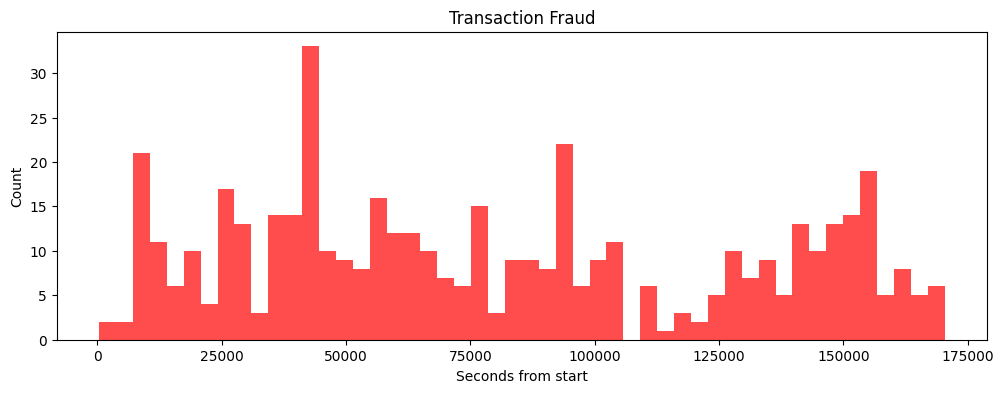

In [123]:
fraud = df[df['Class'] == 1]

plt.figure(figsize=(12, 4))
plt.hist(fraud['Time'], bins=50, alpha=0.7, label='Fraud', color='red')
plt.xlabel('Seconds from start')
plt.ylabel('Count')
plt.title('Transaction Fraud')
plt.show();

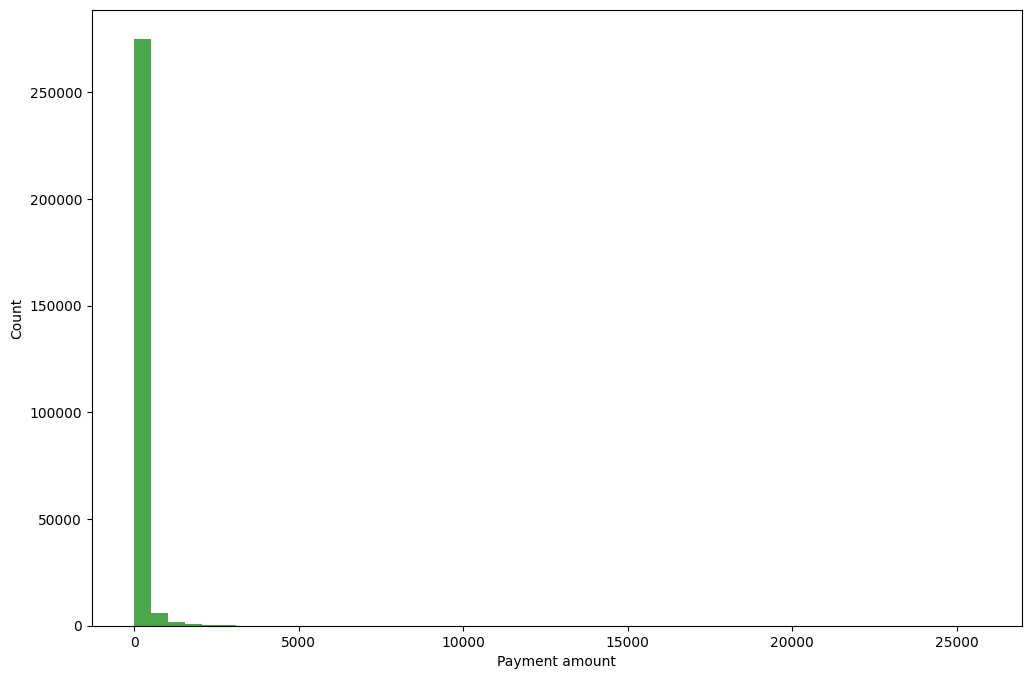

In [124]:
plt.figure(figsize=(12, 8))
plt.hist(df["Amount"], bins=50, alpha=0.7, label='Fraud', color='green')
plt.xlabel("Payment amount")
plt.ylabel("Count")
plt.show();

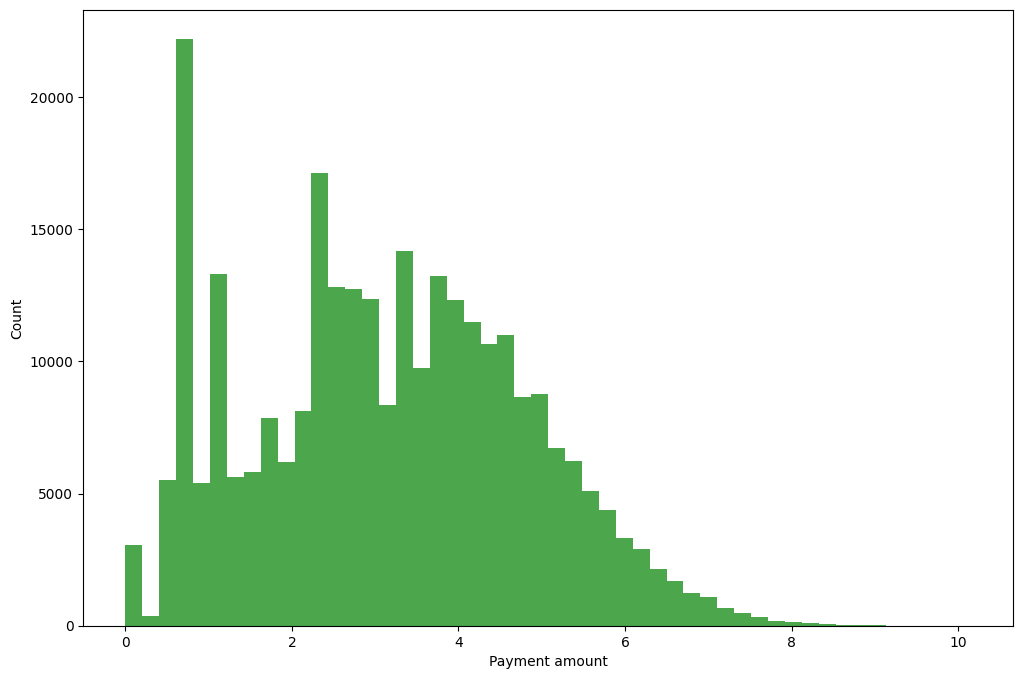

In [125]:
df["Amount_log"] = np.log1p(df["Amount"])
plt.figure(figsize=(12, 8))
plt.hist(df["Amount_log"], bins=50, alpha=0.7, label='Fraud', color='green')
plt.xlabel("Payment amount")
plt.ylabel("Count")
plt.show();

In [126]:
df = df.drop(columns=["Amount"])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539


## Train/Test split

In [130]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

## SMOTE

In [131]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"До SMOTE: {len(y_train)} ({y_train.sum()} фродов)")
print(f"После SMOTE: {len(y_train_resampled)} ({y_train_resampled.sum()} фродов)")
print(f"Баланс: {y_train_resampled.sum()/len(y_train_resampled)*100:.1f}% / {100 - y_train_resampled.sum()/len(y_train_resampled)*100:.1f}%")

До SMOTE: 226980 (378 фродов)
После SMOTE: 453204 (226602 фродов)
Баланс: 50.0% / 50.0%


## Evaluating function

In [135]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"📊 {model_name}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")
    print(f"\nConfusion Matrix:\n{confusion_matrix(y_true, y_pred)}")
    print(f"\nClassification Report:\n{classification_report(y_true, y_pred)}")

## Creating Random Forset model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest')

📊 Random Forest
ROC-AUC: 0.9718

Confusion Matrix:
[[56599    52]
 [   19    76]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.59      0.80      0.68        95

    accuracy                           1.00     56746
   macro avg       0.80      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746

